# Heston Stochastic Volatility Model

This is a basic simulator for a Heston Stochastic Volatility Model, which utilizes the QuantLib library to generate simulations of the HSV model using an efficient C++ implementation.

In [1]:
import pandas as pd
import numpy as np
import jax
import bayesflow as bf
import keras
import QuantLib as ql
import matplotlib.pyplot as plt

INFO:2026-03-01 08:47:13,561:jax._src.xla_bridge:834: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)
INFO:bayesflow:Using backend 'jax'
/Users/kiran.j/PycharmProjects/BayesTool/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Prior Specifications

To start, we specify the prior distributions that we are going to draw from to generate our HSV paths. We start by defining our parameters globally so they are easy to modify if needs be. The distributions we are drawing from will be specified in the functions we actually use to draw priors. We use transformation functions to center our actual distributions around the values we picked.

### Parameters

**v0 - Initial volatility**<br>
The initial value for our volatility path. Because volatility is modeled as a mean-reverting random process, this defines the starting point of our walk

**$\theta$ - Long-run Mean of Volatility**<br>
The long-run mean value for our volatility. It is the value that our volatility process will tend towards after experiencing shocks.

**$\kappa$ - Volatility Mean Reversion Rate**<br>
The speed at which the volatility process returns to its mean value after experiencing a shock. In the volatility process, it is described as $\kappa * (\theta - v_t)$

**$\sigma$ - Volatility of Volatility**<br>
The variance present in our volatility process. It determines the scale of fluctuations in our volatility process, meaning a higher frequency of more extreme volatility events with an increase in this parameter.

**$\rho$ - Return/Volatility Correlation**<br>
The correlation coefficient between the brownian motions used in the price and volatility processes. In real markets, this value is negative, meaning when prices drop, volatility increases.



In [2]:
SPOT_MEAN = 100
SPOT_STD = 15

VOL_MEAN = 0.04
VOL_STD = 0.002

KAPPA_MEAN = 1.0
KAPPA_STD = 0.25

SIGMA_MEAN = 0.66
SIGMA_STD = 0.15

RHO_ALPHA = 2
RHO_BETA = 5

**Prior Distributions**<br>
To draw from our desired distributions, we define a to_lognormal() transformation such that when we draw from a normal distribution with the transformed mean and std and then log transform the output, our resultant log-normal distribution has the originally specified mean and std. We mostly define our variables as transformations from the normal distribution so are prior draws are all similarly scaled (this excludes our draws for sigma and rho, as these values must be bounded and specified differently).

In [3]:
def to_lognormal(mean, std) :
    sigma = np.sqrt(np.log(1 + std**2 / mean**2))
    mu = np.log(mean) - sigma**2 / 2
    return mu, sigma

def to_spot(norm_draw):
    log_mean, log_std = to_lognormal(SPOT_MEAN, SPOT_STD)
    scaled_norm = norm_draw * log_std + log_mean
    return np.exp(scaled_norm)

def to_v0(norm_draw):
    log_mean, log_std = to_lognormal(VOL_MEAN, VOL_STD)
    scaled_norm = norm_draw * (log_std * 2) + log_mean
    return np.exp(scaled_norm)

def to_theta(norm_draw):
    log_mean, log_std = to_lognormal(VOL_MEAN, VOL_STD)
    scaled_norm = norm_draw * log_std + log_mean
    return np.exp(scaled_norm)

def to_kappa(norm_draw):
    log_mean, log_std = to_lognormal(KAPPA_MEAN, KAPPA_STD)
    scaled_norm = norm_draw * log_std + log_mean
    return np.exp(scaled_norm)

def draw_sigma(upper_bound) :
    epsilon = 10 ** (-6)
    return np.random.beta(6, 6) * (0.9 * upper_bound) + epsilon

def draw_rho() :
    # Here we force this value negative and bound it at -0.9 to avoid over-correlating our processes
    return np.random.beta(RHO_ALPHA, RHO_BETA) * -0.9 - 0.05

def draw_priors() :
    spot = np.random.normal()
    v0 = np.random.normal()
    theta = np.random.normal()
    kappa = np.random.normal()
    sigma = draw_sigma(upper_bound=np.sqrt(2*to_kappa(kappa)*to_theta(theta)))
    rho = draw_rho()
    return {"spot":spot,
            "v0":v0,
            "theta":theta,
            "kappa":kappa,
            "sigma":sigma,
            "rho":rho}

## Defining our Simulator

Next, we define our simulator for the Heston Stochastic Volatility model, using QuantLib as the backend for our model for fast calculation. Using a Bayesflow simulator, we combine our draw_priors() function with our single path simulator to create a simulator object that can be used in our workflow


In [4]:
def single_heston_draw(spot, v0, theta, kappa, sigma, rho, steps=2520, dt=1/2520):
    # Transform draws for spot, v0, theta, and kappa into the correct space
    spot = to_spot(spot)
    v0 = to_v0(v0)
    theta = to_theta(theta)
    kappa = to_kappa(kappa)

    spot_quote = ql.SimpleQuote(spot)
    yield_ts = ql.YieldTermStructureHandle(ql.FlatForward(0, ql.UnitedStates(ql.UnitedStates.NYSE), 0.05, ql.Actual365Fixed()))
    div_ts = ql.YieldTermStructureHandle(ql.FlatForward(0, ql.UnitedStates(ql.UnitedStates.NYSE), 0.0, ql.Actual365Fixed()))

    process = ql.HestonProcess(yield_ts, div_ts, ql.QuoteHandle(spot_quote), v0, kappa, theta, sigma, rho, ql.HestonProcess.QuadraticExponentialMartingale)

    # Initialize path arrays
    x = np.zeros(steps + 1)
    v = np.zeros(steps + 1)
    x[0], v[0] = spot, v0

    state = ql.Array(2)
    # we use log prices because the Heston Process uses log prices internally
    state[0], state[1] = np.log(spot), v0

    dw = np.random.standard_normal((steps, 2)) # Standard Normal shocks

    t = 0.0
    for i in range(1, steps + 1):
        state = process.evolve(t, state, dt, ql.Array([dw[i-1, 0], dw[i-1, 1]]))
        x[i] = np.exp(state[0])
        v[i] = state[1]
        t += dt

    return dict(path=x)

simulator = bf.make_simulator([draw_priors, single_heston_draw])

## Prior Checking

In order to confirm the validity of our results, we conduct analysis on the priors we draw to confirm that they look as expected (this will include prior pushforward checks once I can implement these).

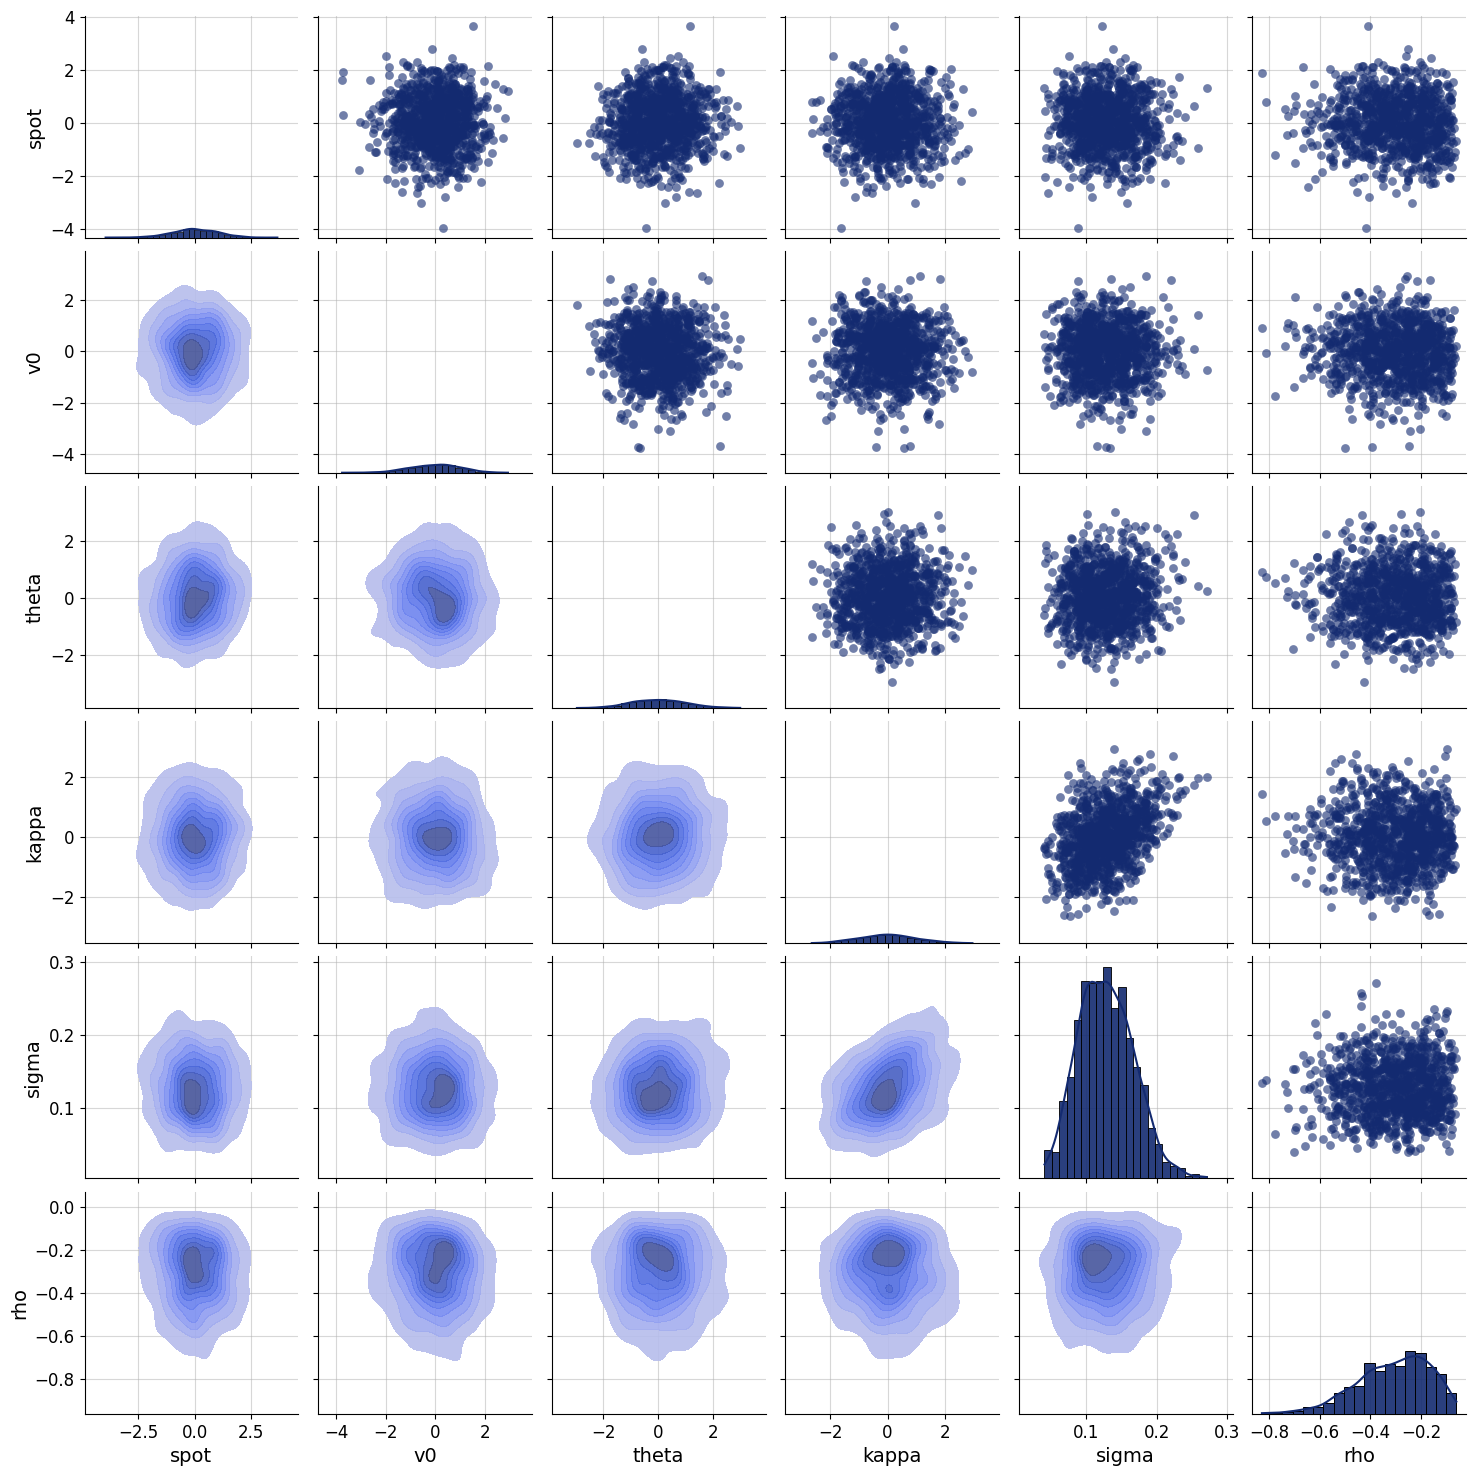

In [5]:
prior_samples = simulator.simulators[0].sample(1000)

grid = bf.diagnostics.plots.pairs_samples(
    prior_samples, variable_keys=["spot", "v0", "theta", "kappa", "sigma", "rho"]
)

## Setting Up Our Workflow

In order to create a fully functioning SBI workflow, we create our Bayesflow workflow object, which involves creating a few different helper objects.

**Adapter**<br>
To start, we create our adapter, which we use to make the data from our simulation palatable to our inference and summary networks.

In [6]:
adapter = (
    bf.adapters.Adapter()
    .convert_dtype("float64", "float32")
    .as_time_series("path")
    .concatenate(["v0", "theta", "kappa", "sigma", "rho"], into="inference_variables")
    .rename("path", "summary_variables")
)

**Creating The Workflow**<br>
Then, we combine all the pieces we have created so far to create our overall workflow, which will combine our simulator, adapter, and summary network with an inference network.

In [7]:
summary_net = bf.networks.TimeSeriesNetwork(dropout=0.1)

inference_net = bf.networks.CouplingFlow(dropout=0.1)

workflow = bf.BasicWorkflow(
    simulator=simulator,
    adapter=adapter,
    summary_network=summary_net,
    inference_network=inference_net,
    checkpoint_path="motion_workflow/"
)

## Training Our Model
Now, we finally get to train our model. We use the workflow we have already created to generate a number of simulations with unique prior draws, which will then train the network to recognize the different parameters we have from the paths we generate, or find in the real world!

In [8]:
train = workflow.simulate(10000)
validation = workflow.simulate(300)

history = workflow.fit_offline(data=train,
                               epochs=100,
                               batch_size=32,
                               validation_data=validation)

INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 133s 418ms/step - loss: 7.0357 - val_loss: 7.0483
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 139s 445ms/step - loss: 6.9922 - val_loss: 7.0577
Epoch 3/100
280/313 ━━━━━━━━━━━━━━━━━━━━ 14s 426ms/step - loss: 6.9948

KeyboardInterrupt: 

## Diagnostics

Finally, we get to see how well our model actually performs! We can do this through a number of different methods.

**Plotting Loss**<br>
To start, we will plot the loss of our inference network. This is not a very effective check for how well our network has actually learned to approximate our posterior distributions, but it does serve as a good negative check -- if this doesn't converge, we need to check our work.

[]

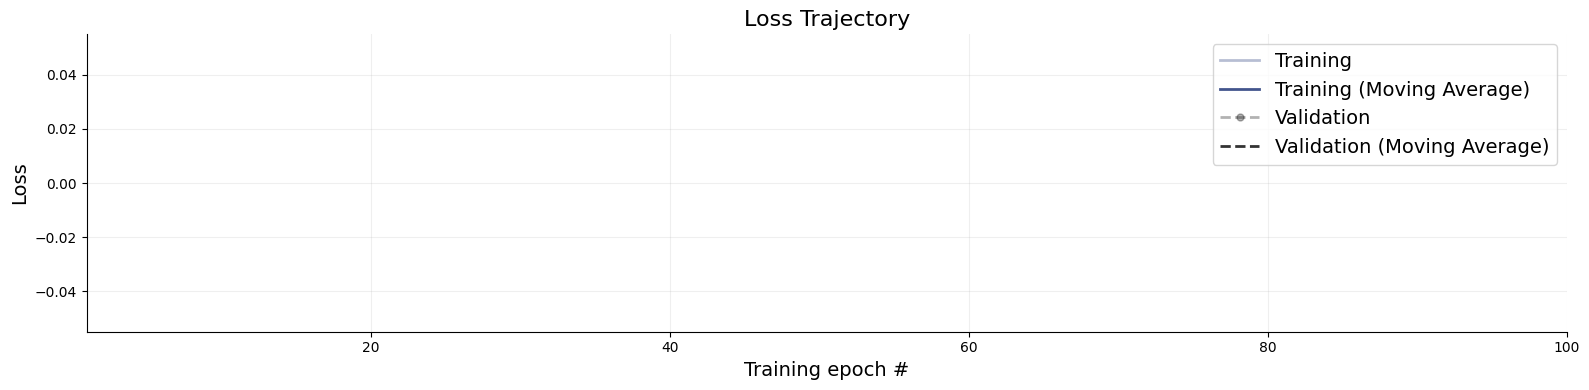

In [28]:
f = bf.diagnostics.plots.loss(history)
plt.plot()

**Checking Recoveries**<br>
We can also check the recoveries of the free parameters in our model, which allows us to understand exactly how well our model has learned our parameters. If we see a lack of correlation here, or a non-linear shape, this indicated issues with our learning, though these may not always be solvable.

In [29]:
num_datasets = 300
num_samples = 1000

# Simulate 300 scenarios
print("Running simulations")
test_sims = workflow.simulate(num_datasets)

# Obtain num_samples posterior samples per scenario
print("Sampling")
samples = workflow.sample(conditions=test_sims, num_samples=num_samples)

print("Making plots")
f = bf.diagnostics.plots.recovery(samples, test_sims)

plt.savefig("overfit_recoveries.png")

Running simulations
Sampling


Sampling:   0%|          | 0/1 [00:12<?, ?batch/s]


RuntimeError: Exception encountered when calling FlowMatching.call().

[1mAll values are NaNs in state during integration at 0.019999999552965164.[0m

Arguments received by FlowMatching.call():
  • xz=jnp.ndarray(shape=(300000, 5), dtype=float32)
  • conditions=jnp.ndarray(shape=(300000, 32), dtype=float32)
  • inverse=True
  • density=False
  • training=False
  • kwargs=<class 'inspect._empty'>

**Posterior Sampling**<br>
Our second-best test for the quality of our model is to look at the actual posterior distributions we get from our model. If we get reasonable and tight posterior distributions, this suggests that our network is fairly confident about the values of the parameters we are trying to estimate. As such, this check can help us figure out how well our model is calibrated.

In [ ]:
labels = ["v0", "theta", "kappa", "sigma", "rho"]

truths = np.asarray([test_sims[labels[x]][0].item() for x in range(len(labels))])

out_samples = np.asarray([samples[labels[x]][0].flatten() for x in range(len(labels))]).T

d = out_samples.shape[1]
fig, axes = plt.subplots(d, d, figsize=(8, 8))

for i in range(d):
    for j in range(d):
        ax = axes[i, j]
        if i == j:
            ax.set_facecolor("white")  # set background blue
            ax.hist(out_samples[:, i], bins=40, histtype="step", color="lightblue")
            ax.axvline(truths[i], color="red")
            ax.set_xlabel(labels[i])
        elif i < j:
            ax.set_facecolor("midnightblue")  # set background blue
            h = ax.hist2d(out_samples[:, j], out_samples[:, i],
                          bins=50, cmap="viridis")
            ax.plot(truths[j], truths[i], "o", color="red")
        else:
            ax.axis("off")

plt.tight_layout()

plt.plot()